# QuVINE Graph Embedding Notebook

This notebook allows you to:
1. Load your own graph data (edge list with optional weights)
2. Choose from various QuVINE methods (quantum walks, baselines, etc.)
3. Generate embeddings for downstream tasks

## Available Methods:
- **Quantum Walk Methods**: `quvine_dtqw`, `quvine_ctqw`, `quvine_rwr`
- **GAT Variants**: `gat_ctqw_heat`, `gat_ctqw_poly`, `gat_dtqw_heat`, `gat_dtqw_poly`, `gat_rwr_heat`, `gat_rwr_poly`
- **Filter Methods**: `filter_ctqw_heat`, `filter_ctqw_poly`, `filter_dtqw_heat`, `filter_dtqw_poly`, `filter_rwr_heat`, `filter_rwr_poly`
- **Baseline Methods**: `node2vec`, `appnp`, `graphsage`, `netmf`, `baseline_gcnmf`, `baseline_gat`, `baseline_graphgps`
- **GraphGPS Variants**: `graphgps_ctqw_heat`, `graphgps_ctqw_poly`, `graphgps_dtqw_heat`, `graphgps_dtqw_poly`, `graphgps_rwr_heat`, `graphgps_rwr_poly`

## 1. Setup and Imports

**Important:** If you encounter import errors after updating QuVINE code, restart the Jupyter kernel:
- Jupyter Notebook: Kernel → Restart
- JupyterLab: Kernel → Restart Kernel
- VS Code: Click the restart button in the notebook toolbar

In [98]:
import sys
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from omegaconf import DictConfig, OmegaConf

# Add QuVINE to path
quvine_path = Path("QuVINE/src")
if quvine_path.exists():
    sys.path.insert(0, str(quvine_path))
else:
    print("Warning: QuVINE source directory not found. Please adjust the path.")

# Force reload of modules to pick up any code changes
import importlib
if 'quvine.embedding.quantum_filters' in sys.modules:
    importlib.reload(sys.modules['quvine.embedding.quantum_filters'])
if 'quvine.baselines.gcn_mf' in sys.modules:
    importlib.reload(sys.modules['quvine.baselines.gcn_mf'])

from quvine.baselines.registry import MethodRegistry
from quvine.baselines.registration import register_all_methods
from quvine.baselines.hyperparameter_loader import HyperparameterLoader, set_global_loader
from quvine.embedding.registry import EmbeddingStore
from quvine.utils.seed import set_global_seed

print("✓ Imports successful!")

✓ Imports successful!


## 2. Load Your Graph Data

You can load graph data in several ways:
- From a CSV file with columns: `node1`, `node2`, (optional) `weight`
- From an edge list
- From a NetworkX graph object

In [99]:
def load_graph_from_csv(filepath, has_weights=False):
    """
    Load graph from CSV file.
    
    Args:
        filepath: Path to CSV file with columns 'node1', 'node2', and optionally 'weight'
        has_weights: Whether the CSV contains edge weights
    
    Returns:
        NetworkX graph
    """
    df = pd.read_csv(filepath)
    
    # Ensure node columns are strings
    df['node1'] = df['node1'].astype(str)
    df['node2'] = df['node2'].astype(str)
    
    if has_weights and 'weight' in df.columns:
        G = nx.from_pandas_edgelist(df, source='node1', target='node2', edge_attr='weight')
    else:
        G = nx.from_pandas_edgelist(df, source='node1', target='node2')
    
    # Get largest connected component
    if not nx.is_connected(G):
        print("Graph is not connected. Extracting largest connected component...")
        giant = max(nx.connected_components(G), key=len)
        G = G.subgraph(giant).copy()
    
    return G


def load_graph_from_edgelist(edges, weights=None):
    """
    Load graph from edge list.
    
    Args:
        edges: List of tuples (node1, node2)
        weights: Optional list of edge weights
    
    Returns:
        NetworkX graph
    """
    G = nx.Graph()
    
    if weights is not None:
        for (u, v), w in zip(edges, weights):
            G.add_edge(str(u), str(v), weight=w)
    else:
        for u, v in edges:
            G.add_edge(str(u), str(v))
    
    # Get largest connected component
    if not nx.is_connected(G):
        print("Graph is not connected. Extracting largest connected component...")
        giant = max(nx.connected_components(G), key=len)
        G = G.subgraph(giant).copy()
    
    return G


def print_graph_stats(G):
    """Print basic graph statistics."""
    print("\n" + "="*50)
    print("GRAPH STATISTICS")
    print("="*50)
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
    print(f"Density: {nx.density(G):.4f}")
    print(f"Is connected: {nx.is_connected(G)}")
    if nx.is_connected(G):
        print(f"Diameter: {nx.diameter(G)}")
        print(f"Average shortest path length: {nx.average_shortest_path_length(G):.2f}")
    print("="*50 + "\n")

### Option A: Load from CSV file

In [100]:
# Example: Load from CSV
# Uncomment and modify the path to your data file

# csv_path = "path/to/your/graph.csv"  # CSV with columns: node1, node2, (optional) weight
# graph_data = load_graph_from_csv(csv_path, has_weights=False)
# print_graph_stats(graph_data)

### Option B: Load from edge list

In [101]:
# Example: Create a sample graph from edge list
edges = [
    ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'), ('D', 'E'), ('D', 'F'),
    ('E', 'F'), ('E', 'G'), ('F', 'G'), ('F', 'H'),
    ('G', 'H'), ('G', 'I'), ('H', 'I')
]

graph_data = load_graph_from_edgelist(edges)
print_graph_stats(graph_data)


GRAPH STATISTICS
Number of nodes: 9
Number of edges: 15
Average degree: 3.33
Density: 0.4167
Is connected: True
Diameter: 4
Average shortest path length: 1.94



### Option C: Use a built-in NetworkX graph

In [102]:
# Example: Use Karate Club graph
# graph_data = nx.karate_club_graph()
# graph_data = nx.relabel_nodes(graph_data, {i: str(i) for i in graph_data.nodes()})
# print_graph_stats(graph_data)

### Visualize the graph (for small graphs)

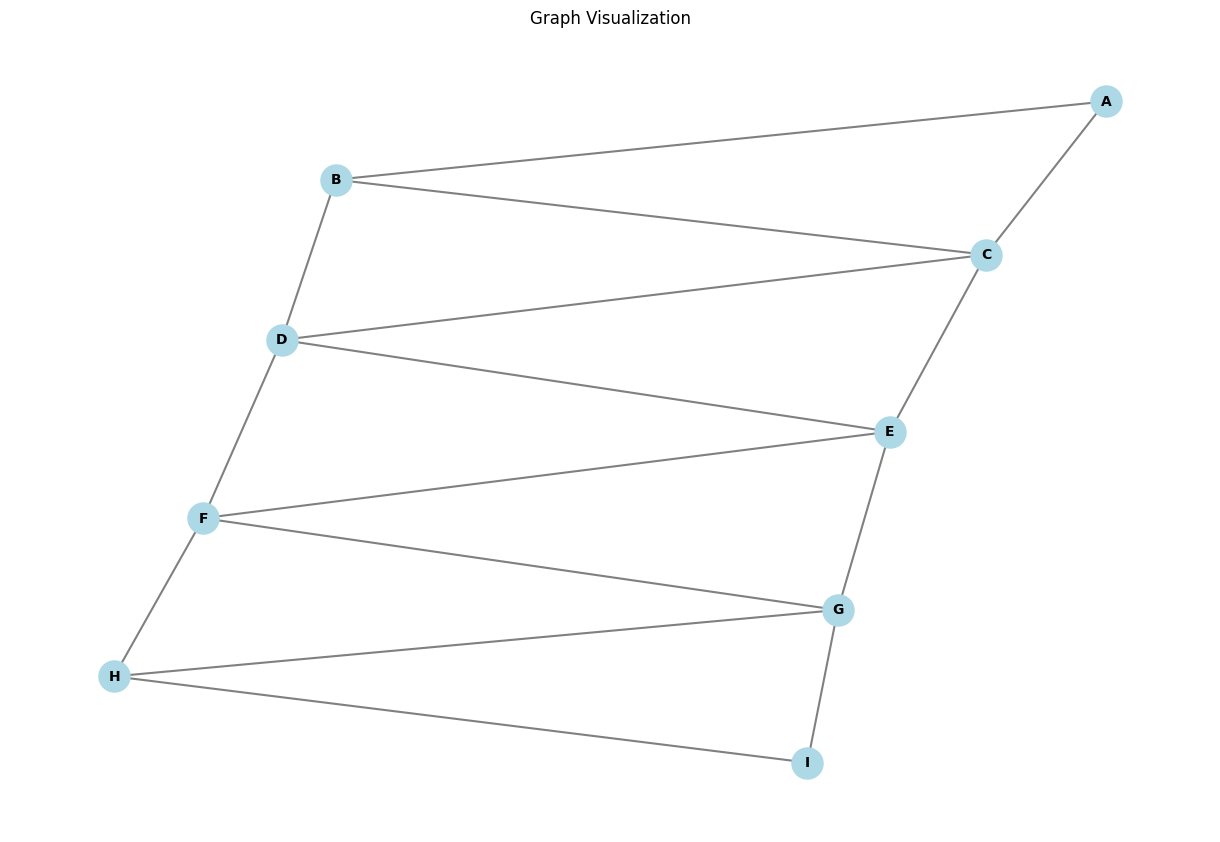

In [103]:
if graph_data.number_of_nodes() < 100:
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph_data, seed=42)
    nx.draw(graph_data, pos, with_labels=True, node_color='lightblue', 
            node_size=500, font_size=10, font_weight='bold', 
            edge_color='gray', width=1.5)
    plt.title("Graph Visualization")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Graph too large to visualize. Skipping visualization.")

## 3. Configure QuVINE Method

Choose which method(s) to run and configure parameters.

In [104]:
# Available methods
AVAILABLE_METHODS = {
    'Quantum Walks (SGNS)': ['quvine_dtqw', 'quvine_ctqw', 'quvine_rwr'],
    'GAT Variants': ['baseline_gat', 'gat_ctqw_heat', 'gat_ctqw_poly', 'gat_dtqw_heat', 
                     'gat_dtqw_poly', 'gat_rwr_heat', 'gat_rwr_poly'],
    'Filter Methods': ['baseline_filter_heat', 'baseline_filter_poly', 'filter_ctqw_heat', 
                       'filter_ctqw_poly', 'filter_dtqw_heat', 'filter_dtqw_poly', 
                       'filter_rwr_heat', 'filter_rwr_poly'],
    'Baseline Methods': ['node2vec', 'appnp', 'graphsage', 'netmf', 'baseline_gcnmf'],
    'GraphGPS Variants': ['baseline_graphgps', 'graphgps_ctqw_heat', 'graphgps_ctqw_poly', 
                          'graphgps_dtqw_heat', 'graphgps_dtqw_poly', 'graphgps_rwr_heat', 
                          'graphgps_rwr_poly']
}

print("Available Methods:")
print("="*50)
for category, methods in AVAILABLE_METHODS.items():
    print(f"\n{category}:")
    for method in methods:
        print(f"  - {method}")

Available Methods:

Quantum Walks (SGNS):
  - quvine_dtqw
  - quvine_ctqw
  - quvine_rwr

GAT Variants:
  - baseline_gat
  - gat_ctqw_heat
  - gat_ctqw_poly
  - gat_dtqw_heat
  - gat_dtqw_poly
  - gat_rwr_heat
  - gat_rwr_poly

Filter Methods:
  - baseline_filter_heat
  - baseline_filter_poly
  - filter_ctqw_heat
  - filter_ctqw_poly
  - filter_dtqw_heat
  - filter_dtqw_poly
  - filter_rwr_heat
  - filter_rwr_poly

Baseline Methods:
  - node2vec
  - appnp
  - graphsage
  - netmf
  - baseline_gcnmf

GraphGPS Variants:
  - baseline_graphgps
  - graphgps_ctqw_heat
  - graphgps_ctqw_poly
  - graphgps_dtqw_heat
  - graphgps_dtqw_poly
  - graphgps_rwr_heat
  - graphgps_rwr_poly


In [105]:
# Select method(s) to run
# You can specify multiple methods as a list
# Note: Start with simpler baseline methods that don't require quantum targets
selected_methods = ['gat_ctqw_heat', 'baseline_filter_heat']  # Example: run Node2Vec and heat filter
# For quantum methods, use: ['filter_ctqw_heat', 'gat_ctqw_heat'] (requires quantum targets)

# Configuration parameters
config = {
    'embedding_dim': 128,        # Dimension of embeddings
    'seed': 42,                  # Random seed for reproducibility
    'verbose': True,             # Print progress
    
    # Walk parameters (for quantum walk methods)
    'num_walks': 10,             # Number of walks per node
    'walk_length': 80,           # Length of each walk
    'window': 10,                # Context window for Word2Vec
    'epochs': 5,                 # Training epochs
    
    # Quantum walk specific
    'ctqw_time': 1.0,            # Time parameter for CTQW
    'ctqw_steps': 20,            # Steps for CTQW
    'dtqw_steps': 25,            # Steps for DTQW
    'dtqw_coin': 'grover',       # Coin operator for DTQW
    'rwr_restart_prob': 0.15,    # Restart probability for RWR
    
    # View parameters
    'num_views': 5,              # Number of views per node
    'max_nodes': 50,             # Max nodes per view
    'max_edges': 100,            # Max edges per view
    'max_degree': 20,            # Max degree in view
}

print(f"\nSelected methods: {selected_methods}")
print(f"Embedding dimension: {config['embedding_dim']}")


Selected methods: ['gat_ctqw_heat', 'baseline_filter_heat']
Embedding dimension: 128


## 4. Create Configuration Object

In [106]:
def create_config(graph_data, config_params, selected_methods):
    """
    Create OmegaConf configuration for QuVINE.
    """
    cfg_dict = {
        'seed': config_params['seed'],
        'verbose': config_params['verbose'],
        
        'experiment': {
            'base_seed': config_params['seed'],
            'iterations': 1,
        },
        
        'runtime': {
            'output_dir': './quvine_output',
            'n_jobs': 1,
            'chunk_size': 100,
        },
        
        'data': {
            'name': 'custom_graph',
        },
        
        'train': {
            'embedding_dim': config_params['embedding_dim'],
            'window': config_params['window'],
            'sg': 1,
            'negative': 5,
            'workers': 4,
            'epochs': config_params['epochs'],
        },
        
        'min_count': 1,
        
        'views': {
            'num_views': config_params['num_views'],
            'max_nodes': config_params['max_nodes'],
            'max_edges': config_params['max_edges'],
            'max_degree': config_params['max_degree'],
            'degree_norm': True,
            'degree_alpha': 0.75,
        },
        
        'walks': {
            'kinds': [],  # Will be set based on method
            'num_walks': config_params['num_walks'],
            'walk_length': config_params['walk_length'],
            'time': config_params['ctqw_time'],
            'steps': config_params['ctqw_steps'],
            'coin': config_params['dtqw_coin'],
            'restart_prob': config_params['rwr_restart_prob'],
            'max_iter': 1000,
        },
        
        'baselines': {
            'enabled': True,
            'quantum_target_max_nodes': 64,
        },
        
        'preprocess': {
            'subsample': {'enabled': False},
            'sparsify': {'enabled': False},
        },
        
        'evaluation': {
            'enabled': False,
        },
        
        'analysis': {
            'enabled': False,
        },
        
        'fusion': {
            'enabled': False,
        },
        
        'save_embeddings': True,
        'plots': False,
    }
    
    # Determine which walk types are needed
    walk_kinds = set()
    for method in selected_methods:
        if 'dtqw' in method or method == 'quvine_dtqw':
            walk_kinds.add('dtqw')
        if 'ctqw' in method or method == 'quvine_ctqw':
            walk_kinds.add('ctqw')
        if 'rwr' in method or method == 'quvine_rwr':
            walk_kinds.add('rwr')
    
    cfg_dict['walks']['kinds'] = list(walk_kinds) if walk_kinds else ['rwr']  # Default to RWR
    
    # Add method-specific configurations with enabled=True
    # This is CRITICAL - each method needs its own config with enabled=True
    for method in selected_methods:
        # Different methods have different config structures
        if method in ['baseline_filter_heat', 'baseline_filter_poly']:
            # These share the 'baseline_filter' config
            cfg_dict['baselines']['baseline_filter'] = {
                'enabled': True,
                'embedding_dim': config_params['embedding_dim'],
                'filter_type': 'heat' if 'heat' in method else 'poly',
            }
        else:
            # Most methods use their own config name
            cfg_dict['baselines'][method] = {
                'enabled': True,
                'embedding_dim': config_params['embedding_dim'],
            }
    
    return OmegaConf.create(cfg_dict)


cfg = create_config(graph_data, config, selected_methods)
print("✓ Configuration created")
print(f"Walk types to use: {cfg.walks.kinds}")
print(f"Enabled methods: {selected_methods}")

✓ Configuration created
Walk types to use: ['ctqw']
Enabled methods: ['gat_ctqw_heat', 'baseline_filter_heat']


## 5. Run QuVINE Methods

This will generate embeddings using the selected method(s).

In [107]:
def run_quvine_methods(graph_data, cfg, selected_methods):
    """
    Run selected QuVINE methods and return embeddings.
    """
    # Set seed
    set_global_seed(cfg.seed)
    
    # Create embedding store
    store = EmbeddingStore()
    
    # For quantum methods, we need to create quantum targets
    # For this notebook, we'll use all nodes as potential targets
    node_order = list(graph_data.nodes())
    node_to_idx = {node: i for i, node in enumerate(node_order)}
    
    # Create simple quantum targets (using all nodes)
    q_targets = []
    max_support = 64
    
    for center in node_order[:min(len(node_order), 10)]:  # Use first 10 nodes as centers
        try:
            lengths = nx.single_source_shortest_path_length(graph_data, center, cutoff=2)
            support_nodes = [node for node, dist in lengths.items() if dist <= 2]
        except:
            support_nodes = [center]
        
        if center not in support_nodes:
            support_nodes.append(center)
        if len(support_nodes) > max_support:
            support_nodes = support_nodes[:max_support]
        
        center_idx = node_to_idx[center]
        support_idx = np.array([node_to_idx[node] for node in support_nodes], dtype=np.int64)
        dist = np.abs(support_idx - center_idx).astype(np.float64) + 1.0
        p = 1.0 / dist
        p = p / p.sum()
        q_targets.append({"nodes": support_nodes, "center": center, "pQ": p})
    
    # Create and populate method registry
    registry = MethodRegistry(cfg, base_seed=cfg.seed, verbose=cfg.verbose)
    register_all_methods(registry)
    
    if cfg.verbose:
        print(f"\nRegistered {len(registry)} total methods")
        print(f"Running {len(selected_methods)} selected method(s)...\n")
    
    # Run only selected methods
    results = []
    for method_name in selected_methods:
        if method_name in registry.list_methods():
            print(f"\n{'='*60}")
            print(f"Running: {method_name}")
            print(f"{'='*60}")
            
            result = registry.run_method(
                method_name=method_name,
                graph_data=graph_data,
                q_targets=q_targets
            )
            results.append(result)
            
            if result.success:
                print(f"✓ {method_name} completed in {result.execution_time:.2f} seconds")
                # Manually add embedding to store
                if result.embedding is not None:
                    store.add(method_name, result.embedding)
                    print(f"  Added embedding to store: shape {result.embedding.shape}")
            else:
                print(f"✗ {method_name} failed: {result.error}")
        else:
            print(f"Warning: Method '{method_name}' not found in registry")
    
    # Summary
    successful = sum(1 for r in results if r.success)
    print(f"\n{'='*60}")
    print(f"SUMMARY")
    print(f"{'='*60}")
    print(f"Total methods run: {len(results)}")
    print(f"Successful: {successful}")
    print(f"Failed: {len(results) - successful}")
    print(f"{'='*60}\n")
    
    return store, results


# Run the methods
embedding_store, method_results = run_quvine_methods(graph_data, cfg, selected_methods)


Registered 30 total methods
Running 2 selected method(s)...


Running: gat_ctqw_heat
✓ gat_ctqw_heat: 0.00 minutes
✓ gat_ctqw_heat completed in 0.06 seconds
  Added embedding to store: shape (9, 128)

Running: baseline_filter_heat
✓ baseline_filter_heat: 0.00 minutes
✓ baseline_filter_heat completed in 0.00 seconds
  Added embedding to store: shape (9, 128)

SUMMARY
Total methods run: 2
Successful: 2
Failed: 0



## 6. Access and Analyze Embeddings

The embeddings are now stored and ready for downstream tasks.

In [108]:
# List available embeddings
print("Available embeddings:")
print("="*50)
for name in embedding_store.names():
    emb = embedding_store.get(name)
    print(f"  {name}: shape {emb.shape}")
print("="*50)

Available embeddings:
  gat_ctqw_heat: shape (9, 128)
  baseline_filter_heat: shape (9, 128)


In [109]:
# Get embeddings for a specific method
def get_embedding(method_name):
    """
    Retrieve embedding for a specific method.
    """
    if method_name in embedding_store.names():
        return embedding_store.get(method_name)
    else:
        print(f"Embedding '{method_name}' not found.")
        print(f"Available: {embedding_store.names()}")
        return None

# Example: Get embedding for first method
if len(selected_methods) > 0 and selected_methods[0] in embedding_store.names():
    example_embedding = get_embedding(selected_methods[0])
    print(f"\nExample embedding shape: {example_embedding.shape}")
    print(f"Embedding dimension: {example_embedding.shape[1]}")
    print(f"Number of nodes: {example_embedding.shape[0]}")


Example embedding shape: (9, 128)
Embedding dimension: 128
Number of nodes: 9


## 7. Visualize Embeddings (2D projection)

Use PCA to visualize embeddings in 2D. PCA is fast and works well for most cases.


Visualizing embeddings for 2 method(s)...

Visualizing gat_ctqw_heat embeddings...
Original embedding shape: (9, 128)
Explained variance ratio: [0.73689383 0.23890284]
Total variance explained: 97.58%
Total nodes plotted: 9
Embedding shape: (9, 2)

Checking for overlapping nodes...
⚠️  Found 4 overlapping node pair(s):
  - Nodes A and I are 0.000002 apart (nearly identical embeddings)
  - Nodes B and H are 0.000000 apart (nearly identical embeddings)
  - Nodes C and G are 0.000000 apart (nearly identical embeddings)
  - Nodes D and F are 0.000000 apart (nearly identical embeddings)

Node positions in 2D:
  A: (2.5906, -1.3693)
  B: (1.3923, 0.5940)
  C: (-0.0735, 1.7399)
  D: (-2.2755, -0.3062)
  E: (-3.2677, -1.3167)
  F: (-2.2755, -0.3062)
  G: (-0.0735, 1.7399)
  H: (1.3923, 0.5940)
  I: (2.5906, -1.3693)

📊 Analyzing graph structure for overlapping nodes:

  Nodes A and I:
    Degrees: 2 vs 2
    Neighbors of A: ['B', 'C']
    Neighbors of I: ['G', 'H']
    Common neighbors: [] (0

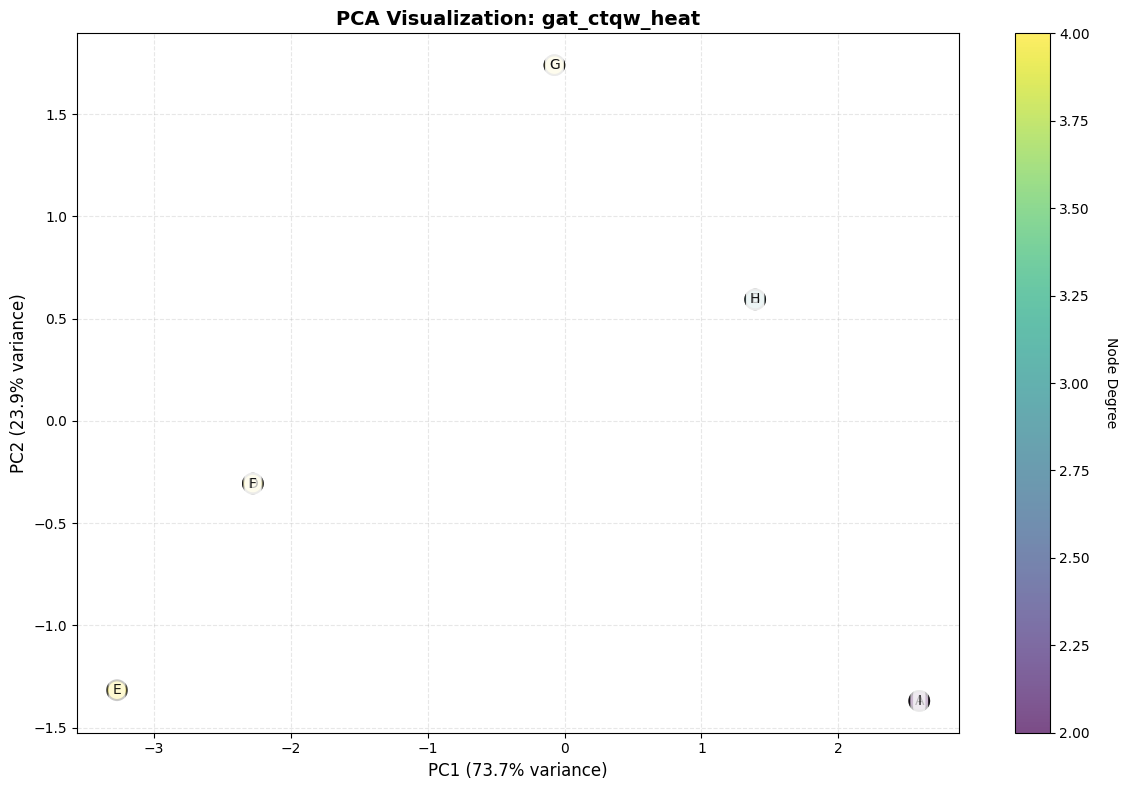


Visualizing baseline_filter_heat embeddings...
Original embedding shape: (9, 128)
Explained variance ratio: [0.51235142 0.18817808]
Total variance explained: 70.05%
Total nodes plotted: 9
Embedding shape: (9, 2)

Checking for overlapping nodes...
✓ No overlapping nodes detected

Node positions in 2D:
  A: (0.2957, -0.2439)
  B: (0.3581, -0.1188)
  C: (0.3053, -0.0393)
  D: (0.1924, 0.2674)
  E: (0.0546, 0.1834)
  F: (-0.1512, 0.2296)
  G: (-0.3322, -0.0029)
  H: (-0.3710, -0.1050)
  I: (-0.3518, -0.1705)


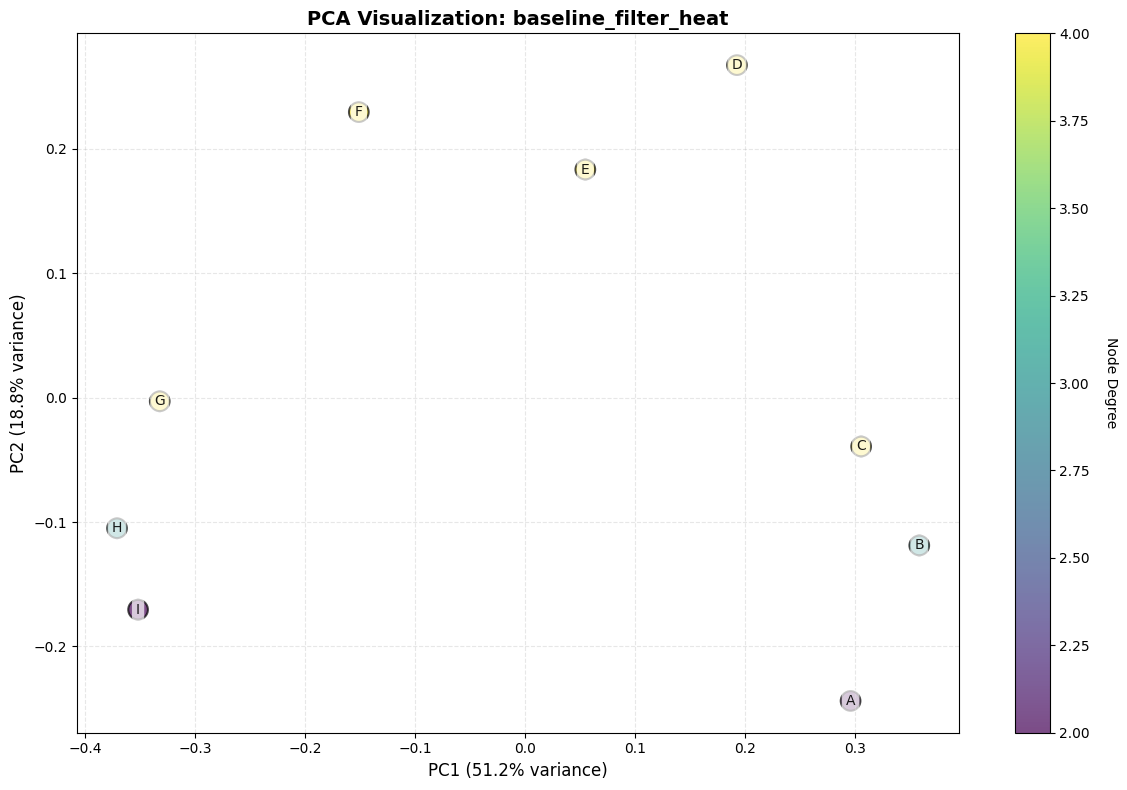

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_embedding_pca(embedding, method_name, nodes):
    """
    Visualize embeddings in 2D using PCA.
    """
    if embedding is None:
        print(f"No embedding found for {method_name}")
        return
    
    print(f"\nVisualizing {method_name} embeddings...")
    print(f"Original embedding shape: {embedding.shape}")
    
    # Apply PCA to reduce to 2D
    pca = PCA(n_components=2, random_state=42)
    embedding_2d = pca.fit_transform(embedding)
    
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color nodes by degree if graph is available
    if 'graph_data' in globals():
        degrees = [graph_data.degree[node] for node in nodes]
        scatter = ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                           c=degrees, cmap='viridis', alpha=0.7, s=200, edgecolors='black', linewidth=1.5)
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Node Degree', rotation=270, labelpad=20)
    else:
        ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.7, s=200, edgecolors='black', linewidth=1.5)
    
    # Add labels for ALL nodes in small graphs
    if len(nodes) < 30:
        for i, node in enumerate(nodes):
            ax.annotate(str(node), (embedding_2d[i, 0], embedding_2d[i, 1]), 
                       fontsize=10, alpha=0.9, ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Print node count for verification
    print(f"Total nodes plotted: {len(nodes)}")
    print(f"Embedding shape: {embedding_2d.shape}")
    
    # Check for overlapping nodes (nodes with very similar 2D coordinates)
    print(f"\nChecking for overlapping nodes...")
    overlap_threshold = 0.01  # Consider nodes overlapping if within this distance
    overlaps = []
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            dist = np.linalg.norm(embedding_2d[i] - embedding_2d[j])
            if dist < overlap_threshold:
                overlaps.append((nodes[i], nodes[j], dist))
    
    if overlaps:
        print(f"⚠️  Found {len(overlaps)} overlapping node pair(s):")
        for n1, n2, dist in overlaps:
            print(f"  - Nodes {n1} and {n2} are {dist:.6f} apart (nearly identical embeddings)")
    else:
        print("✓ No overlapping nodes detected")
    
    # Print all node positions for debugging
    print(f"\nNode positions in 2D:")
    for i, node in enumerate(nodes):
        print(f"  {node}: ({embedding_2d[i, 0]:.4f}, {embedding_2d[i, 1]:.4f})")
    
    # Analyze graph structure for overlapping nodes
    if overlaps and 'graph_data' in globals():
        print(f"\n📊 Analyzing graph structure for overlapping nodes:")
        for n1, n2, dist in overlaps:
            deg1 = graph_data.degree[n1]
            deg2 = graph_data.degree[n2]
            neighbors1 = set(graph_data.neighbors(n1))
            neighbors2 = set(graph_data.neighbors(n2))
            common = neighbors1 & neighbors2
            print(f"\n  Nodes {n1} and {n2}:")
            print(f"    Degrees: {deg1} vs {deg2}")
            print(f"    Neighbors of {n1}: {sorted(neighbors1)}")
            print(f"    Neighbors of {n2}: {sorted(neighbors2)}")
            print(f"    Common neighbors: {sorted(common)} ({len(common)} shared)")
            if neighbors1 == neighbors2:
                print(f"    ⚠️  IDENTICAL neighborhoods - explains identical embeddings!")
    
    ax.set_title(f"PCA Visualization: {method_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    return embedding_2d, pca

# Visualize embeddings for each method
nodes = list(graph_data.nodes())
print(f"\nVisualizing embeddings for {len(selected_methods)} method(s)...")
print("="*60)

for method_name in selected_methods:
    if method_name in embedding_store.names():
        emb = get_embedding(method_name)
        if emb is not None:
            embedding_2d, pca_model = visualize_embedding_pca(emb, method_name, nodes)
    else:
        print(f"\nSkipping {method_name} - embedding not found")

## 8. Save Embeddings

Save embeddings to disk for later use.

In [111]:
def save_embeddings(embedding_store, nodes, output_dir="./embeddings_output"):
    """
    Save all embeddings to disk.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Save as NPZ (compressed numpy format)
    npz_payload = {
        name: emb.astype(np.float32)
        for name, emb in embedding_store.items()
    }
    npz_payload['nodes'] = np.array(nodes)
    
    npz_path = os.path.join(output_dir, "embeddings.npz")
    np.savez_compressed(npz_path, **npz_payload)
    print(f"✓ Saved embeddings to {npz_path}")
    
    # Also save as CSV for each method
    for name, emb in embedding_store.items():
        df = pd.DataFrame(emb, index=nodes)
        df.index.name = 'node'
        csv_path = os.path.join(output_dir, f"{name}_embeddings.csv")
        df.to_csv(csv_path)
        print(f"✓ Saved {name} to {csv_path}")
    
    print(f"\nAll embeddings saved to {output_dir}/")

# Save embeddings
save_embeddings(embedding_store, list(graph_data.nodes()))

✓ Saved embeddings to ./embeddings_output/embeddings.npz
✓ Saved gat_ctqw_heat to ./embeddings_output/gat_ctqw_heat_embeddings.csv
✓ Saved baseline_filter_heat to ./embeddings_output/baseline_filter_heat_embeddings.csv

All embeddings saved to ./embeddings_output/


## 9. Load Saved Embeddings (for later use)

In [112]:
def load_saved_embeddings(npz_path="./embeddings_output/embeddings.npz"):
    """
    Load previously saved embeddings.
    """
    data = np.load(npz_path, allow_pickle=True)
    
    nodes = data['nodes']
    embeddings = {}
    
    for key in data.files:
        if key != 'nodes':
            embeddings[key] = data[key]
    
    print(f"Loaded {len(embeddings)} embeddings for {len(nodes)} nodes")
    return embeddings, nodes

# Example: Load embeddings
# loaded_embeddings, loaded_nodes = load_saved_embeddings()

## 10. Example Downstream Tasks

Here are some examples of how to use the embeddings for downstream tasks.

### A. Node Similarity

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_nodes(node, embedding, nodes, top_k=5):
    """
    Find most similar nodes to a given node.
    """
    if node not in nodes:
        print(f"Node '{node}' not found in graph")
        return
    
    node_idx = list(nodes).index(node)
    node_emb = embedding[node_idx].reshape(1, -1)
    
    # Compute similarities
    similarities = cosine_similarity(node_emb, embedding)[0]
    
    # Get top-k (excluding the node itself)
    top_indices = np.argsort(similarities)[::-1][1:top_k+1]
    
    print(f"\nTop {top_k} nodes similar to '{node}':")
    for i, idx in enumerate(top_indices, 1):
        print(f"  {i}. {nodes[idx]} (similarity: {similarities[idx]:.4f})")

# Example: Find similar nodes
if len(selected_methods) > 0 and selected_methods[0] in embedding_store.names():
    example_node = list(graph_data.nodes())[0]
    emb = get_embedding(selected_methods[0])
    find_similar_nodes(example_node, emb, list(graph_data.nodes()), top_k=5)


Top 5 nodes similar to 'A':
  1. I (similarity: 1.0000)
  2. H (similarity: 0.5259)
  3. B (similarity: 0.5259)
  4. E (similarity: -0.1989)
  5. F (similarity: -0.3164)


### B. Node Clustering

In [114]:
from sklearn.cluster import KMeans

def cluster_nodes(embedding, nodes, n_clusters=3):
    """
    Cluster nodes based on embeddings.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(embedding)
    
    # Group nodes by cluster
    cluster_dict = {i: [] for i in range(n_clusters)}
    for node, cluster_id in zip(nodes, clusters):
        cluster_dict[cluster_id].append(node)
    
    print(f"\nNode Clustering (k={n_clusters}):")
    for cluster_id, cluster_nodes in cluster_dict.items():
        print(f"\nCluster {cluster_id} ({len(cluster_nodes)} nodes):")
        print(f"  {cluster_nodes[:10]}{'...' if len(cluster_nodes) > 10 else ''}")
    
    return clusters

# Example: Cluster nodes
if len(selected_methods) > 0 and selected_methods[0] in embedding_store.names():
    emb = get_embedding(selected_methods[0])
    clusters = cluster_nodes(emb, list(graph_data.nodes()), n_clusters=3)


Node Clustering (k=3):

Cluster 0 (3 nodes):
  ['D', 'E', 'F']

Cluster 1 (4 nodes):
  ['B', 'C', 'G', 'H']

Cluster 2 (2 nodes):
  ['A', 'I']


### C. Link Prediction

In [115]:
def predict_links(embedding, nodes, graph, top_k=10):
    """
    Predict potential new links based on embedding similarity.
    """
    # Compute all pairwise similarities
    similarities = cosine_similarity(embedding)
    
    # Find non-existing edges with high similarity
    predictions = []
    for i, node1 in enumerate(nodes):
        for j, node2 in enumerate(nodes):
            if i < j and not graph.has_edge(node1, node2):
                predictions.append((node1, node2, similarities[i, j]))
    
    # Sort by similarity
    predictions.sort(key=lambda x: x[2], reverse=True)
    
    print(f"\nTop {top_k} predicted links:")
    for i, (node1, node2, sim) in enumerate(predictions[:top_k], 1):
        print(f"  {i}. {node1} -- {node2} (score: {sim:.4f})")
    
    return predictions[:top_k]

# Example: Predict links
if len(selected_methods) > 0 and selected_methods[0] in embedding_store.names():
    emb = get_embedding(selected_methods[0])
    predicted_links = predict_links(emb, list(graph_data.nodes()), graph_data, top_k=10)


Top 10 predicted links:
  1. B -- H (score: 1.0000)
  2. C -- G (score: 1.0000)
  3. A -- I (score: 1.0000)
  4. B -- I (score: 0.5259)
  5. A -- H (score: 0.5259)
  6. C -- F (score: 0.4320)
  7. D -- G (score: 0.4320)
  8. C -- H (score: 0.4097)
  9. B -- G (score: 0.4097)
  10. E -- H (score: -0.1145)


## Summary

This notebook demonstrated how to:
1. Load custom graph data
2. Select and configure QuVINE methods
3. Generate embeddings
4. Visualize and analyze embeddings
5. Use embeddings for downstream tasks (similarity, clustering, link prediction)

The embeddings are now ready for any downstream machine learning task!